In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.ensemble import RandomForestRegressor

import shap

c:\Users\pepetorres\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_DIR = Path.cwd().parent

DATA_PROCESSED = BASE_DIR / "data" / "processed"

df = pd.read_csv(
    DATA_PROCESSED / "dataset_scored_final.csv"
)

print(df.shape)

(174, 59)


In [3]:
features = [

    "poblacion_2025",

    "precio_venta_eur_m2",

    "precio_alquiler_eur_m2_mes",

    "suelo_residencial_m2_por_hab",

    "reserva_suelo_hab",

    "indice_expansion",

    "distancia_capital_km",

    "distancia_costa_km"

]

In [4]:
target = "CoopScore_4"

In [5]:
X = df[features].copy()

X = X.fillna(
    X.median(numeric_only=True)
)

y = df[target]

In [6]:
modelo = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

modelo.fit(
    X,
    y
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [7]:
importance = pd.DataFrame({

    "variable": features,

    "importance": modelo.feature_importances_

})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,variable,importance
0,poblacion_2025,0.492579
7,distancia_costa_km,0.128481
4,reserva_suelo_hab,0.099392
5,indice_expansion,0.092411
2,precio_alquiler_eur_m2_mes,0.067307
6,distancia_capital_km,0.055979
3,suelo_residencial_m2_por_hab,0.034261
1,precio_venta_eur_m2,0.029590


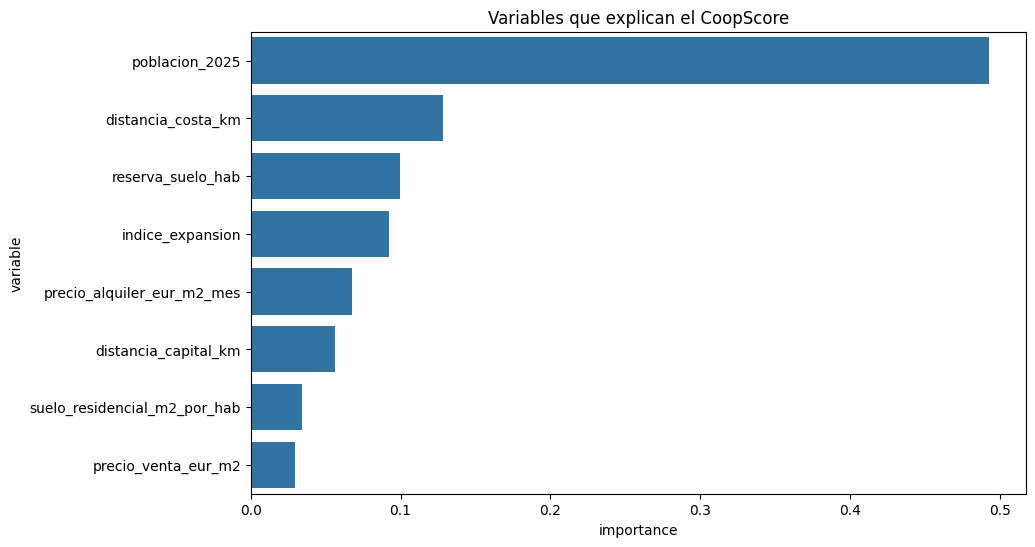

In [8]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="importance",
    y="variable"
)

plt.title(
    "Variables que explican el CoopScore"
)

plt.show()

In [9]:
explainer = shap.TreeExplainer(
    modelo
)

shap_values = explainer.shap_values(
    X
)

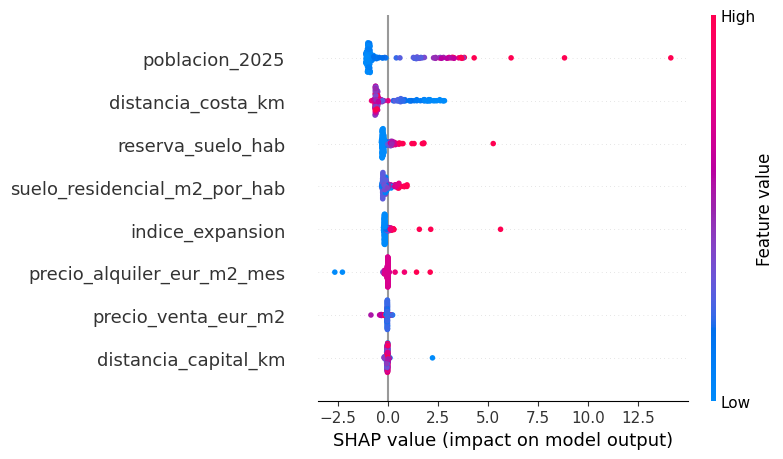

In [10]:
shap.summary_plot(
    shap_values,
    X
)

In [11]:
municipios_clave = [

    "Granada",

    "Motril",

    "Salobreña",

    "Almuñécar",

    "Pinos Genil"

]

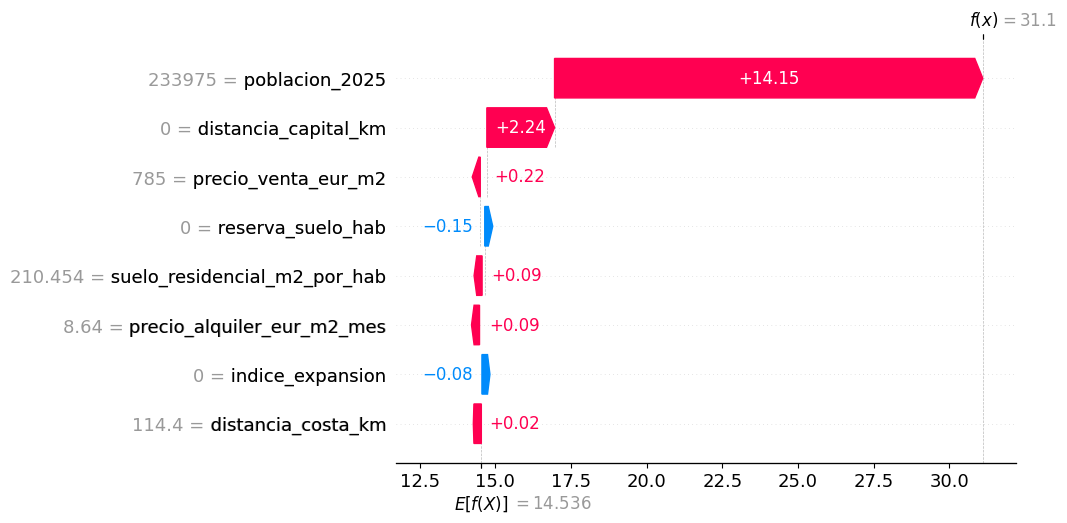

In [12]:
idx = df[
    df["municipio"] == "Granada"
].index[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X.iloc[idx],
        feature_names=X.columns
    )
)

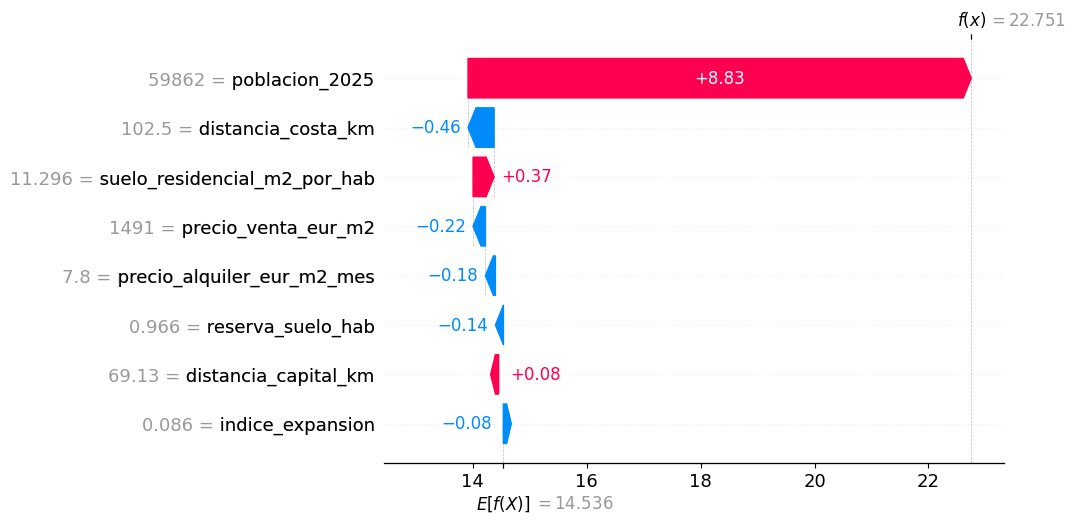

In [13]:
idx = df[
    df["municipio"] == "Motril"
].index[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X.iloc[idx],
        feature_names=X.columns
    )
)

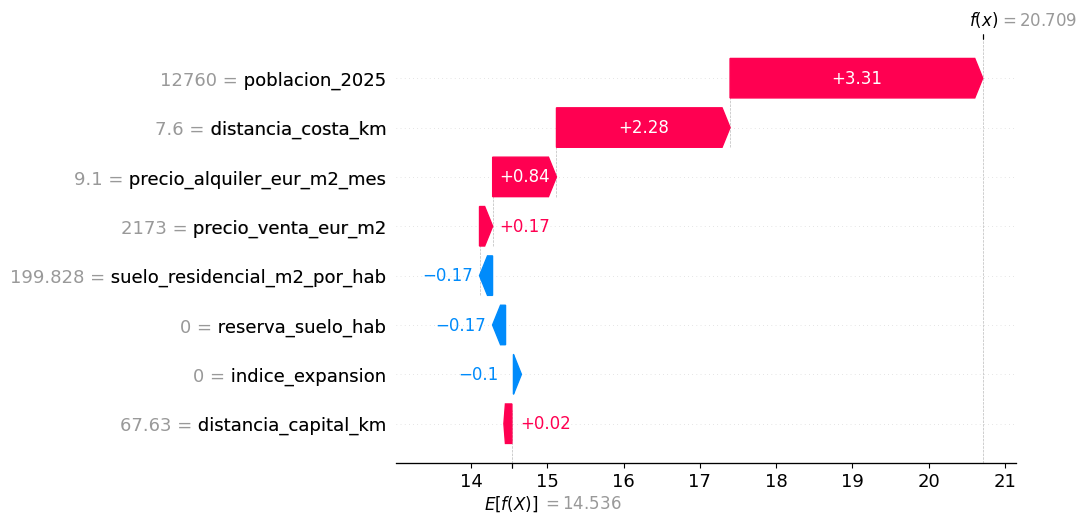

In [17]:
idxs = df[df["municipio"].str.lower() == "salobreña"].index
if idxs.empty:
    raise ValueError("Municipio 'Salobreña' not found in df['municipio']")
idx = idxs[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X.iloc[idx],
        feature_names=X.columns
    )
)

In [16]:
importance

,variable,importance
0,poblacion_2025,0.492579
7,distancia_costa_km,0.128481
4,reserva_suelo_hab,0.099392
5,indice_expansion,0.092411
2,precio_alquiler_eur_m2_mes,0.067307
6,distancia_capital_km,0.055979
3,suelo_residencial_m2_por_hab,0.034261
1,precio_venta_eur_m2,0.029590


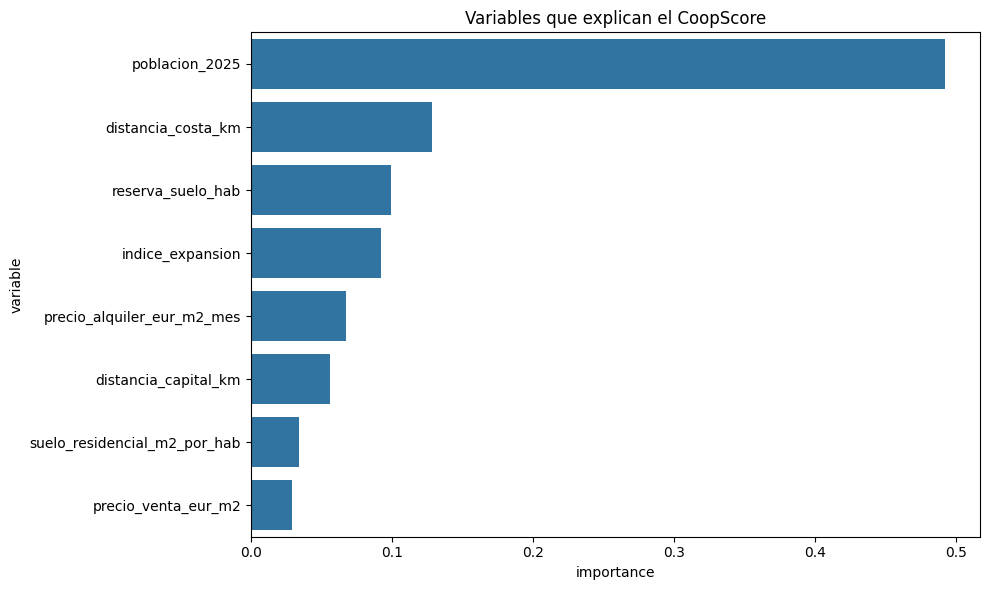

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="importance",
    y="variable"
)

plt.title(
    "Variables que explican el CoopScore"
)

plt.tight_layout()

plt.show()

In [19]:
from sklearn.metrics import r2_score

pred = modelo.predict(X)

print(
    "R²:",
    round(
        r2_score(y, pred),
        4
    )
)

R²: 0.938


In [20]:
explainer = shap.TreeExplainer(modelo)

shap_values = explainer.shap_values(X)

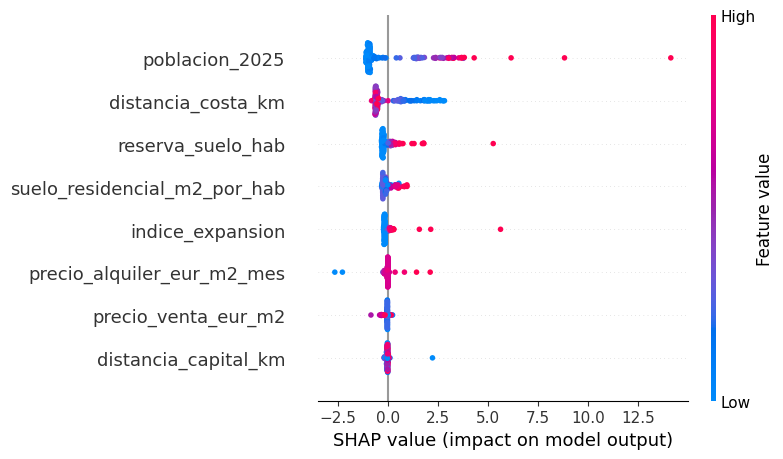

In [21]:
shap.summary_plot(
    shap_values,
    X
)

# Interpretabilidad del CoopScore mediante SHAP

El modelo **Random Forest** entrenado para explicar el **CoopScore** alcanza un coeficiente de determinación (**R² = 0,938**), lo que indica una elevada capacidad para reproducir la puntuación obtenida mediante el sistema de indicadores desarrollado.

## Importancia de las variables

El análisis de importancia de variables muestra que la **población municipal** constituye el principal factor explicativo del CoopScore. Este resultado refleja la influencia que tienen los municipios con mayor masa crítica de población sobre el potencial económico y residencial de la provincia.

Entre las variables territoriales destacan la **distancia a la costa**, la **reserva de suelo disponible por habitante** y el **índice de expansión urbanística**, factores que aportan información complementaria al tamaño poblacional y permiten identificar municipios con capacidad de crecimiento futuro.

## Análisis SHAP

El análisis SHAP confirma que los municipios más poblados generan contribuciones positivas sobre la puntuación final del modelo. Asimismo, la proximidad al litoral y la disponibilidad de suelo urbanizable incrementan el valor estimado del CoopScore, mientras que una mayor distancia a los principales polos de actividad económica tiende a reducirlo.

Los resultados muestran que variables asociadas al desarrollo territorial y urbanístico tienen una influencia significativa sobre la puntuación final, validando la hipótesis inicial de que el potencial municipal no depende exclusivamente de factores demográficos o económicos.

## Validación del modelo

La combinación de métricas de rendimiento, importancia de variables y análisis SHAP permite concluir que el CoopScore incorpora de forma coherente factores demográficos, urbanísticos, económicos y territoriales.

La elevada capacidad explicativa del modelo refuerza la robustez metodológica del índice y facilita la interpretación de los factores que determinan el potencial de desarrollo de los municipios de la provincia de Granada.

## Conclusiones

Los resultados obtenidos evidencian que el potencial de desarrollo municipal está condicionado por una combinación de factores relacionados con:

- Tamaño y dinámica poblacional.
- Disponibilidad de suelo para futuros desarrollos.
- Potencial de expansión urbanística.
- Accesibilidad territorial.
- Proximidad a la costa y a los principales centros de actividad.

En consecuencia, el CoopScore permite identificar municipios con diferentes perfiles de desarrollo, facilitando la toma de decisiones en ámbitos como la planificación urbanística, la inversión inmobiliaria y el análisis territorial.